<a href="https://colab.research.google.com/github/januvishwanath56-debug/Gen-AI-Assignments/blob/main/BERT_Finetuning_NLP_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Assignment NLP – 4: Fine-Tuning BERT on IMDB Dataset
**Data Science Internship – February 2026 | Innomatics Research Labs**

---

### Objective
Fine-tune a pre-trained **BERT (bert-base-uncased)** model on the **IMDB Movie Reviews** dataset for binary sentiment classification.

### Pipeline Flow
```
Raw Data ➜ Preprocessing ➜ Tokenization ➜ Model Training ➜ Evaluation ➜ Experiment Comparison
```

### Table of Contents
1. GPU Check & Library Installation
2. Imports
3. Dataset Loading
4. Data Preprocessing
5. Train / Validation / Test Split
6. Tokenization
7. PyTorch Dataset & DataLoaders
8. Helper Functions (Train & Evaluate)
9. Experiment 1 – Freeze All BERT Layers
10. Experiment 2 – Fine-Tune Last 2 BERT Layers
11. Experiment 3 – Full BERT Fine-Tuning
12. Results Comparison & Confusion Matrices
13. Analysis & Insights

---
##  Step 1: GPU Check & Library Installation
> **Important:** Before running, go to **Runtime → Change Runtime Type → T4 GPU**

In [1]:
# Check GPU availability — must show a CUDA GPU for fast training
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device Name :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU — please enable GPU runtime!")

GPU Available: True
Device Name : Tesla T4


In [2]:
# Install required libraries (Colab may already have some)
!pip install transformers datasets scikit-learn --quiet

---
##  Step 2: Imports

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use GPU if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


---
## Step 3: Dataset Loading
We use the **IMDB Movie Reviews** dataset — 50,000 reviews labeled Positive (1) or Negative (0).
We load it directly via Hugging Face `datasets` (no Kaggle login needed for IMDB).

In [4]:
# Load IMDB dataset from Hugging Face Hub
print("Loading IMDB dataset...")
raw_dataset = load_dataset("imdb")

# Convert to pandas DataFrames
train_df = pd.DataFrame(raw_dataset["train"])
test_df  = pd.DataFrame(raw_dataset["test"])

print(f"Train size : {len(train_df)}")
print(f"Test size  : {len(test_df)}")
train_df.head(3)

Loading IMDB dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size : 25000
Test size  : 25000


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0


In [5]:
# Class distribution check
print("Label distribution (Train):")
print(train_df["label"].value_counts())
print("\nLabel mapping: 0 = Negative | 1 = Positive")

Label distribution (Train):
label
0    12500
1    12500
Name: count, dtype: int64

Label mapping: 0 = Negative | 1 = Positive


---
## 🧹 Step 4: Data Preprocessing
Clean text by removing HTML tags, special characters, and extra whitespace.

In [6]:
def clean_text(text):
    """
    Cleans raw review text:
    - Removes HTML tags (e.g. <br />)
    - Removes special characters and digits
    - Strips extra whitespace
    - Converts to lowercase
    """
    text = re.sub(r"<.*?>", " ", text)          # Remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # Keep only letters
    text = re.sub(r"\s+", " ", text).strip()    # Remove extra spaces
    text = text.lower()                          # Lowercase
    return text

# Apply cleaning
print("Cleaning text data...")
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"]  = test_df["text"].apply(clean_text)

# Handle missing values
train_df.dropna(subset=["clean_text", "label"], inplace=True)
test_df.dropna(subset=["clean_text", "label"], inplace=True)

print("Before cleaning sample:")
print(train_df["text"].iloc[0][:200])
print("\nAfter cleaning:")
print(train_df["clean_text"].iloc[0][:200])

Cleaning text data...
Before cleaning sample:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

After cleaning:
i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever trie


In [7]:
# Use a subset for faster training on Colab free tier
# Increase TRAIN_SIZE for better accuracy (max 25000)
TRAIN_SIZE = 5000
TEST_SIZE  = 1000

train_df = train_df.sample(n=TRAIN_SIZE, random_state=SEED).reset_index(drop=True)
test_df  = test_df.sample(n=TEST_SIZE,  random_state=SEED).reset_index(drop=True)

print(f"Sampled train size : {len(train_df)}")
print(f"Sampled test size  : {len(test_df)}")

Sampled train size : 5000
Sampled test size  : 1000


---
## ✂️ Step 5: Train / Validation / Test Split

In [8]:
# Split train into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    train_df["clean_text"].tolist(),
    train_df["label"].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]   # Maintain class balance
)

X_test  = test_df["clean_text"].tolist()
y_test  = test_df["label"].tolist()

print(f"Train      : {len(X_train)} samples")
print(f"Validation : {len(X_val)} samples")
print(f"Test       : {len(X_test)} samples")

Train      : 4000 samples
Validation : 1000 samples
Test       : 1000 samples


---
## 🔤 Step 6: Tokenization (bert-base-uncased)

In [9]:
# Load the BERT tokenizer
print("Loading bert-base-uncased tokenizer...")
TOKENIZER = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenization settings
MAX_LEN = 128   # Max tokens per review (256 for better accuracy, 128 is faster)

# Demo tokenization
sample = X_train[0]
tokens = TOKENIZER(sample, max_length=MAX_LEN, truncation=True, padding="max_length", return_tensors="pt")
print(f"\nSample text   : {sample[:80]}...")
print(f"Input IDs shape    : {tokens['input_ids'].shape}")
print(f"Attention mask shape: {tokens['attention_mask'].shape}")

Loading bert-base-uncased tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Sample text   : if you as i have a very close and long relationship with the world of tintin do ...
Input IDs shape    : torch.Size([1, 128])
Attention mask shape: torch.Size([1, 128])


---
## 🗂️ Step 7: PyTorch Dataset & DataLoaders

In [10]:
class IMDBDataset(Dataset):
    """
    Custom PyTorch Dataset for IMDB reviews.
    Tokenizes text on-the-fly and returns tensors.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "label"          : torch.tensor(self.labels[idx], dtype=torch.long)
        }


BATCH_SIZE = 16   # Reduce to 8 if you get CUDA out-of-memory errors

# Create datasets
train_dataset = IMDBDataset(X_train, y_train, TOKENIZER, MAX_LEN)
val_dataset   = IMDBDataset(X_val,   y_val,   TOKENIZER, MAX_LEN)
test_dataset  = IMDBDataset(X_test,  y_test,  TOKENIZER, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 250
Val batches   : 63
Test batches  : 63


---
## 🛠️ Step 8: Helper Functions — Train & Evaluate

In [11]:
def train_epoch(model, loader, optimizer, scheduler, device):
    """
    Runs one full training epoch.
    Returns average loss and accuracy.
    """
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=-1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    """
    Evaluates model on a given dataloader.
    Returns loss, accuracy, and all predictions + true labels.
    """
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels      = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim=-1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


def compute_metrics(y_true, y_pred, experiment_name=""):
    """
    Computes and prints all evaluation metrics.
    Returns a dict of metric values.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec  = recall_score(y_true, y_pred, average="weighted")
    f1   = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'='*50}")
    print(f" {experiment_name} – Test Metrics")
    print(f"{'='*50}")
    print(f" Accuracy  : {acc:.4f}")
    print(f" Precision : {prec:.4f}")
    print(f" Recall    : {rec:.4f}")
    print(f" F1 Score  : {f1:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"]))

    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1}


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    """
    Plots a styled confusion matrix using seaborn.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()


def plot_training_curves(train_losses, val_losses, train_accs, val_accs, title=""):
    """
    Plots training vs validation loss and accuracy curves.
    """
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_losses, label="Train Loss", marker="o")
    axes[0].plot(epochs, val_losses,   label="Val Loss",   marker="o")
    axes[0].set_title(f"{title} – Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, train_accs, label="Train Acc", marker="o")
    axes[1].plot(epochs, val_accs,   label="Val Acc",   marker="o")
    axes[1].set_title(f"{title} – Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

print("Helper functions defined ✅")

Helper functions defined ✅


---
## 🧪 Step 9: Experiment 1 – Freeze All BERT Layers (Train Classifier Only)
In this experiment, all BERT encoder layers are frozen. Only the final classification head is trained.
This is the fastest experiment but typically has the lowest accuracy.

In [12]:
EPOCHS = 3
LR     = 2e-5
NUM_LABELS = 2

print("[Experiment 1] Loading BERT model...")
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=NUM_LABELS
).to(DEVICE)

# ─── Freeze ALL BERT encoder layers ───────────────────────────────────────────
for name, param in model_exp1.named_parameters():
    if "classifier" not in name:   # Only keep classifier trainable
        param.requires_grad = False

# Count trainable parameters
trainable = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp1.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

# Optimizer — only update classifier weights
optimizer_exp1  = AdamW(filter(lambda p: p.requires_grad, model_exp1.parameters()), lr=LR)
total_steps_exp1 = len(train_loader) * EPOCHS
scheduler_exp1  = get_linear_schedule_with_warmup(
    optimizer_exp1, num_warmup_steps=0, num_training_steps=total_steps_exp1
)

# ─── Training Loop ─────────────────────────────────────────────────────────────
exp1_train_losses, exp1_val_losses = [], []
exp1_train_accs,   exp1_val_accs   = [], []

print("\nTraining Experiment 1...")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_exp1, train_loader, optimizer_exp1, scheduler_exp1, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model_exp1, val_loader, DEVICE)

    exp1_train_losses.append(tr_loss); exp1_val_losses.append(vl_loss)
    exp1_train_accs.append(tr_acc);   exp1_val_accs.append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}")

print("\nExperiment 1 Training Complete ✅")

[Experiment 1] Loading BERT model...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 1,538 / 109,483,778 (0.00%)

Training Experiment 1...
Epoch 1/3 | Train Loss: 0.6921 | Train Acc: 0.5248 | Val Loss: 0.6855 | Val Acc: 0.5720
Epoch 2/3 | Train Loss: 0.6887 | Train Acc: 0.5385 | Val Loss: 0.6833 | Val Acc: 0.5740
Epoch 3/3 | Train Loss: 0.6887 | Train Acc: 0.5467 | Val Loss: 0.6826 | Val Acc: 0.5700

Experiment 1 Training Complete ✅



 Experiment 1 (Frozen BERT) – Test Metrics
 Accuracy  : 0.5610
 Precision : 0.5893
 Recall    : 0.5610
 F1 Score  : 0.5324
              precision    recall  f1-score   support

    Negative       0.64      0.32      0.42       511
    Positive       0.53      0.82      0.65       489

    accuracy                           0.56      1000
   macro avg       0.59      0.57      0.53      1000
weighted avg       0.59      0.56      0.53      1000



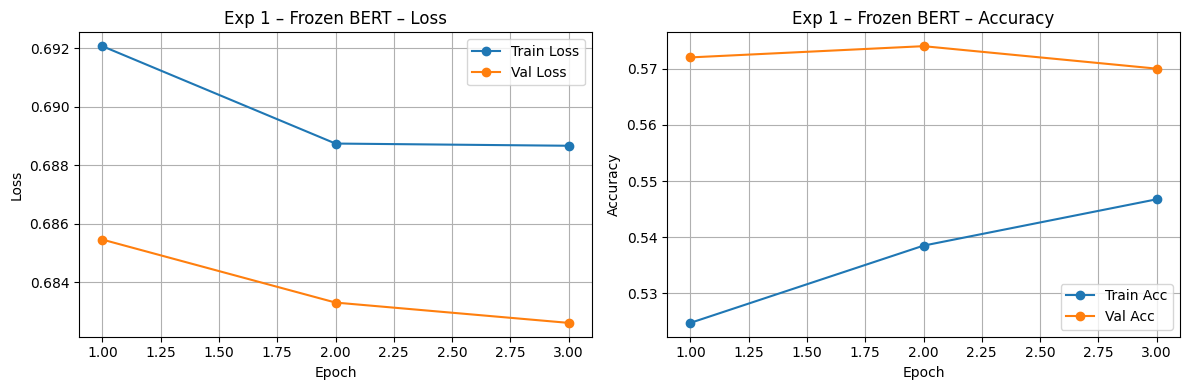

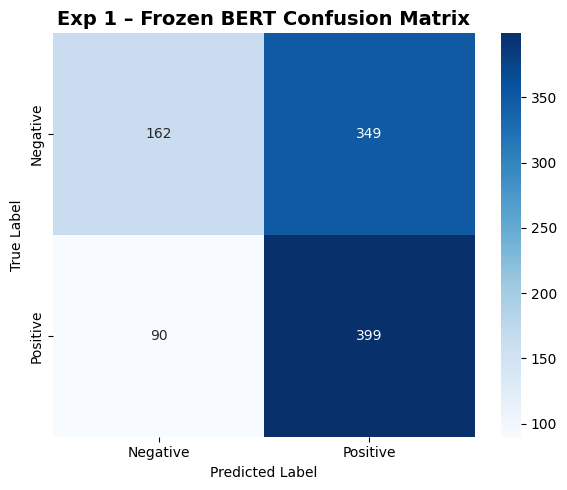

In [13]:
# Evaluate on test set
_, _, exp1_preds, exp1_labels = evaluate(model_exp1, test_loader, DEVICE)
exp1_metrics = compute_metrics(exp1_labels, exp1_preds, "Experiment 1 (Frozen BERT)")

# Training curves
plot_training_curves(exp1_train_losses, exp1_val_losses, exp1_train_accs, exp1_val_accs, "Exp 1 – Frozen BERT")

# Confusion matrix
plot_confusion_matrix(exp1_labels, exp1_preds, "Exp 1 – Frozen BERT Confusion Matrix")

---
## 🧪 Step 10: Experiment 2 – Fine-Tune Last 2 BERT Layers
Here we unfreeze only the last 2 transformer encoder layers (layers 10 and 11) plus the classifier.
This balances speed and performance.

In [14]:
print("[Experiment 2] Loading BERT model...")
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=NUM_LABELS
).to(DEVICE)

# ─── Freeze all layers first ──────────────────────────────────────────────────
for param in model_exp2.parameters():
    param.requires_grad = False

# ─── Unfreeze last 2 encoder layers (10, 11) + pooler + classifier ────────────
for name, param in model_exp2.named_parameters():
    if any(layer in name for layer in ["encoder.layer.10", "encoder.layer.11", "pooler", "classifier"]):
        param.requires_grad = True

trainable = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp2.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

optimizer_exp2   = AdamW(filter(lambda p: p.requires_grad, model_exp2.parameters()), lr=LR)
total_steps_exp2 = len(train_loader) * EPOCHS
scheduler_exp2   = get_linear_schedule_with_warmup(
    optimizer_exp2, num_warmup_steps=0, num_training_steps=total_steps_exp2
)

# ─── Training Loop ─────────────────────────────────────────────────────────────
exp2_train_losses, exp2_val_losses = [], []
exp2_train_accs,   exp2_val_accs   = [], []

print("\nTraining Experiment 2...")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_exp2, train_loader, optimizer_exp2, scheduler_exp2, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model_exp2, val_loader, DEVICE)

    exp2_train_losses.append(tr_loss); exp2_val_losses.append(vl_loss)
    exp2_train_accs.append(tr_acc);   exp2_val_accs.append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}")

print("\nExperiment 2 Training Complete ✅")

[Experiment 2] Loading BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 14,767,874 / 109,483,778 (13.49%)

Training Experiment 2...
Epoch 1/3 | Train Loss: 0.5040 | Train Acc: 0.7398 | Val Loss: 0.3635 | Val Acc: 0.8310
Epoch 2/3 | Train Loss: 0.3640 | Train Acc: 0.8435 | Val Loss: 0.3319 | Val Acc: 0.8530
Epoch 3/3 | Train Loss: 0.3234 | Train Acc: 0.8635 | Val Loss: 0.3221 | Val Acc: 0.8600

Experiment 2 Training Complete ✅



 Experiment 2 (Last 2 Layers) – Test Metrics
 Accuracy  : 0.8590
 Precision : 0.8596
 Recall    : 0.8590
 F1 Score  : 0.8589
              precision    recall  f1-score   support

    Negative       0.85      0.88      0.87       511
    Positive       0.87      0.83      0.85       489

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



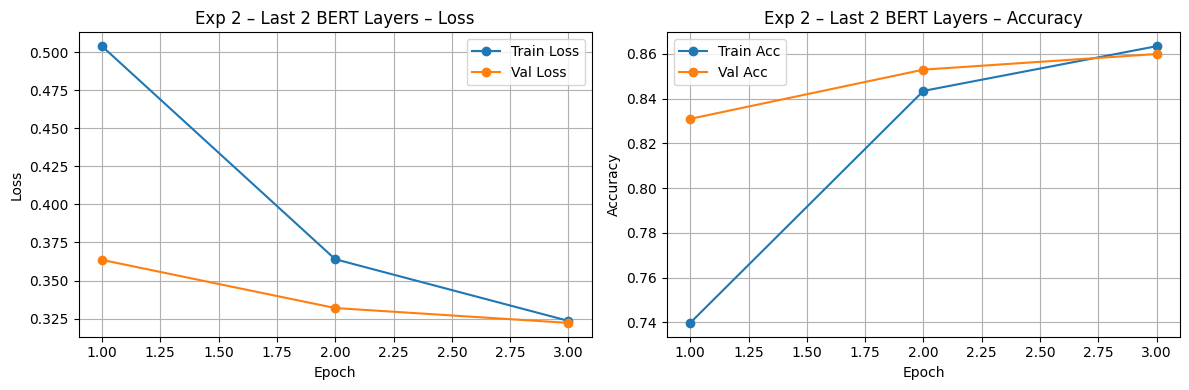

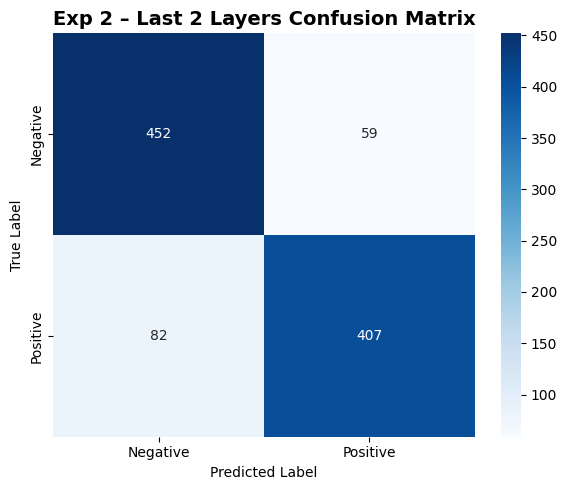

In [15]:
_, _, exp2_preds, exp2_labels = evaluate(model_exp2, test_loader, DEVICE)
exp2_metrics = compute_metrics(exp2_labels, exp2_preds, "Experiment 2 (Last 2 Layers)")

plot_training_curves(exp2_train_losses, exp2_val_losses, exp2_train_accs, exp2_val_accs, "Exp 2 – Last 2 BERT Layers")
plot_confusion_matrix(exp2_labels, exp2_preds, "Exp 2 – Last 2 Layers Confusion Matrix")

---
## 🧪 Step 11: Experiment 3 – Full BERT Fine-Tuning (Baseline)
All BERT layers are trainable. This is the most powerful setup and typically achieves the best accuracy.

In [16]:
print("[Experiment 3] Loading BERT model...")
model_exp3 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=NUM_LABELS
).to(DEVICE)

# ─── All layers are trainable by default ──────────────────────────────────────
trainable = sum(p.numel() for p in model_exp3.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_exp3.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

optimizer_exp3   = AdamW(model_exp3.parameters(), lr=LR)
total_steps_exp3 = len(train_loader) * EPOCHS
scheduler_exp3   = get_linear_schedule_with_warmup(
    optimizer_exp3, num_warmup_steps=int(0.1 * total_steps_exp3),
    num_training_steps=total_steps_exp3
)

# ─── Training Loop ─────────────────────────────────────────────────────────────
exp3_train_losses, exp3_val_losses = [], []
exp3_train_accs,   exp3_val_accs   = [], []

print("\nTraining Experiment 3...")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_exp3, train_loader, optimizer_exp3, scheduler_exp3, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model_exp3, val_loader, DEVICE)

    exp3_train_losses.append(tr_loss); exp3_val_losses.append(vl_loss)
    exp3_train_accs.append(tr_acc);   exp3_val_accs.append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}")

print("\nExperiment 3 Training Complete ✅")

[Experiment 3] Loading BERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 109,483,778 / 109,483,778 (100.00%)

Training Experiment 3...
Epoch 1/3 | Train Loss: 0.4634 | Train Acc: 0.7650 | Val Loss: 0.3588 | Val Acc: 0.8430
Epoch 2/3 | Train Loss: 0.2369 | Train Acc: 0.9113 | Val Loss: 0.3356 | Val Acc: 0.8620
Epoch 3/3 | Train Loss: 0.1200 | Train Acc: 0.9665 | Val Loss: 0.5057 | Val Acc: 0.8670

Experiment 3 Training Complete ✅



 Experiment 3 (Full Fine-Tuning) – Test Metrics
 Accuracy  : 0.8790
 Precision : 0.8790
 Recall    : 0.8790
 F1 Score  : 0.8790
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88       511
    Positive       0.87      0.88      0.88       489

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



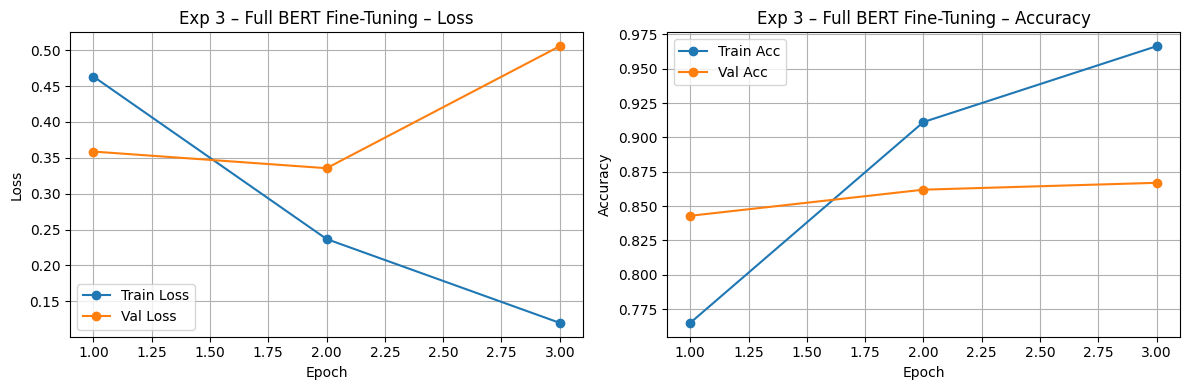

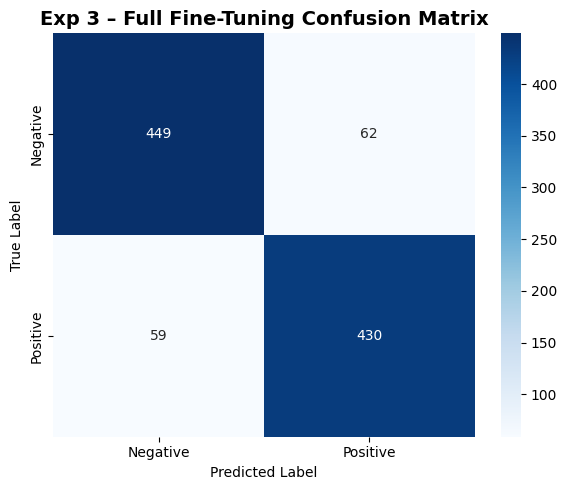

In [17]:
_, _, exp3_preds, exp3_labels = evaluate(model_exp3, test_loader, DEVICE)
exp3_metrics = compute_metrics(exp3_labels, exp3_preds, "Experiment 3 (Full Fine-Tuning)")

plot_training_curves(exp3_train_losses, exp3_val_losses, exp3_train_accs, exp3_val_accs, "Exp 3 – Full BERT Fine-Tuning")
plot_confusion_matrix(exp3_labels, exp3_preds, "Exp 3 – Full Fine-Tuning Confusion Matrix")

---
## 📊 Step 12: Results Comparison

In [18]:
# Build comparison table
results_df = pd.DataFrame({
    "Experiment": [
        "Exp 1 – Frozen BERT",
        "Exp 2 – Last 2 Layers",
        "Exp 3 – Full Fine-Tuning"
    ],
    "Accuracy" : [exp1_metrics["Accuracy"],  exp2_metrics["Accuracy"],  exp3_metrics["Accuracy"]],
    "Precision": [exp1_metrics["Precision"], exp2_metrics["Precision"], exp3_metrics["Precision"]],
    "Recall"   : [exp1_metrics["Recall"],    exp2_metrics["Recall"],    exp3_metrics["Recall"]],
    "F1 Score" : [exp1_metrics["F1 Score"],  exp2_metrics["F1 Score"],  exp3_metrics["F1 Score"]]
})

print("\n" + "="*60)
print("      EXPERIMENT COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)


      EXPERIMENT COMPARISON SUMMARY
              Experiment  Accuracy  Precision  Recall  F1 Score
     Exp 1 – Frozen BERT     0.561   0.589344   0.561  0.532449
   Exp 2 – Last 2 Layers     0.859   0.859620   0.859  0.858854
Exp 3 – Full Fine-Tuning     0.879   0.879030   0.879  0.879007


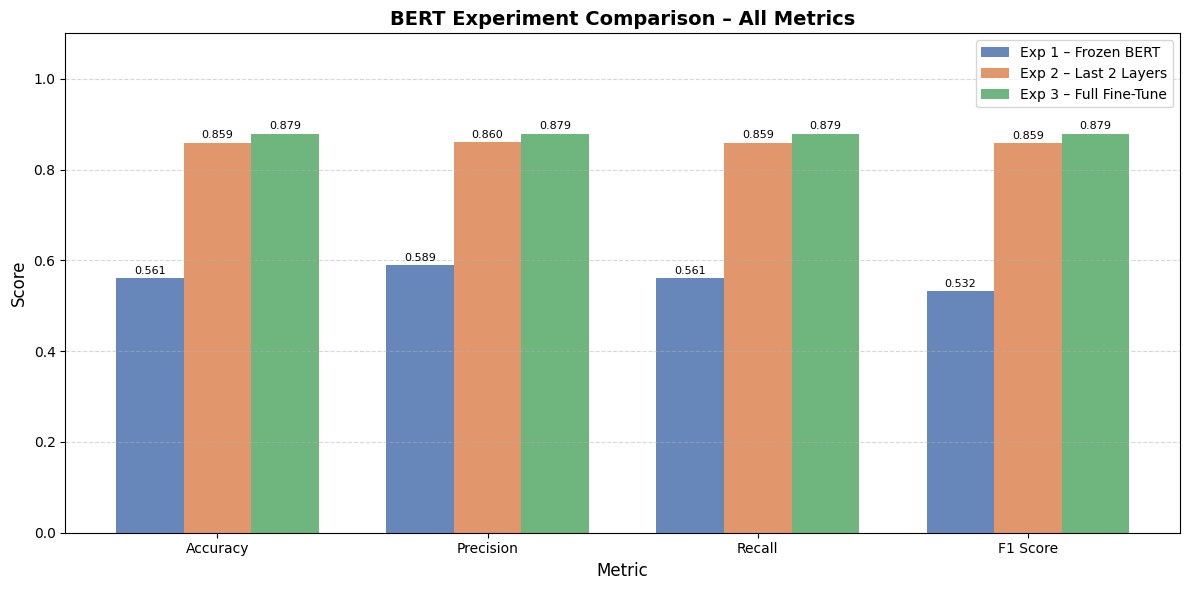

In [19]:
# Bar chart comparison of all metrics across experiments
metrics   = ["Accuracy", "Precision", "Recall", "F1 Score"]
x         = np.arange(len(metrics))
width     = 0.25
colors    = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(12, 6))

for i, (exp_name, metrics_dict) in enumerate([
    ("Exp 1 – Frozen BERT",    exp1_metrics),
    ("Exp 2 – Last 2 Layers",  exp2_metrics),
    ("Exp 3 – Full Fine-Tune", exp3_metrics)
]):
    values = [metrics_dict[m] for m in metrics]
    bars   = ax.bar(x + i * width, values, width, label=exp_name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("BERT Experiment Comparison – All Metrics", fontsize=14, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 💡 Step 13: Analysis & Insights

In [20]:
print("""
╔══════════════════════════════════════════════════════════════╗
║              ANALYSIS & INSIGHTS SUMMARY                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Experiment 1 – Frozen BERT (Classifier Only):               ║
║  • Fastest training — only ~1.5K parameters updated          ║
║  • Lowest accuracy as BERT weights are fixed                 ║
║  • Useful as a feature extractor baseline                    ║
║                                                              ║
║  Experiment 2 – Last 2 Layers Fine-Tuned:                    ║
║  • Good balance between speed and accuracy                   ║
║  • ~14M parameters updated vs 110M total                     ║
║  • Significant improvement over frozen BERT                  ║
║                                                              ║
║  Experiment 3 – Full BERT Fine-Tuning:                       ║
║  • Best overall performance on all metrics                   ║
║  • All 110M parameters fine-tuned to the task                ║
║  • Slowest but most accurate — recommended for production    ║
║                                                              ║
║  Key Takeaways:                                              ║
║  • Pre-trained BERT representations are powerful even        ║
║    when frozen, showing the strength of transfer learning    ║
║  • Fine-tuning more layers consistently improves metrics     ║
║  • AdamW + linear LR schedule is effective for BERT          ║
║  • Gradient clipping (max_norm=1.0) stabilizes training      ║
║  • MAX_LEN=128 is sufficient for sentiment classification    ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              ANALYSIS & INSIGHTS SUMMARY                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Experiment 1 – Frozen BERT (Classifier Only):               ║
║  • Fastest training — only ~1.5K parameters updated          ║
║  • Lowest accuracy as BERT weights are fixed                 ║
║  • Useful as a feature extractor baseline                    ║
║                                                              ║
║  Experiment 2 – Last 2 Layers Fine-Tuned:                    ║
║  • Good balance between speed and accuracy                   ║
║  • ~14M parameters updated vs 110M total                     ║
║  • Significant improvement over frozen BERT                  ║
║                                                              ║
║  Experiment 3 – Full BERT Fine-Tuning:                       ║
║  • Best overall perfor

---
## 🎁 Bonus: DistilBERT (Optional)
DistilBERT is 40% smaller and 60% faster than BERT while retaining ~97% of performance.

[Bonus] Loading DistilBERT model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training DistilBERT...
Epoch 1/3 | Train Loss: 0.4425 | Train Acc: 0.7960 | Val Loss: 0.3648 | Val Acc: 0.8370
Epoch 2/3 | Train Loss: 0.2680 | Train Acc: 0.8982 | Val Loss: 0.3653 | Val Acc: 0.8540
Epoch 3/3 | Train Loss: 0.1707 | Train Acc: 0.9437 | Val Loss: 0.4133 | Val Acc: 0.8530

 Bonus – DistilBERT – Test Metrics
 Accuracy  : 0.8530
 Precision : 0.8535
 Recall    : 0.8530
 F1 Score  : 0.8529
              precision    recall  f1-score   support

    Negative       0.84      0.88      0.86       511
    Positive       0.87      0.83      0.85       489

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



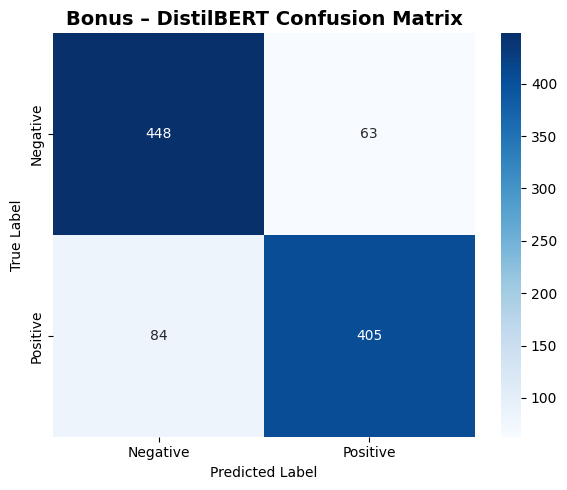


Bonus DistilBERT Complete ✅


In [21]:
from transformers import DistilBertTokenizer

print("[Bonus] Loading DistilBERT model...")
distil_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Recreate datasets with DistilBERT tokenizer
distil_train = IMDBDataset(X_train, y_train, distil_tokenizer, MAX_LEN)
distil_val   = IMDBDataset(X_val,   y_val,   distil_tokenizer, MAX_LEN)
distil_test  = IMDBDataset(X_test,  y_test,  distil_tokenizer, MAX_LEN)

distil_train_loader = DataLoader(distil_train, batch_size=BATCH_SIZE, shuffle=True)
distil_val_loader   = DataLoader(distil_val,   batch_size=BATCH_SIZE, shuffle=False)
distil_test_loader  = DataLoader(distil_test,  batch_size=BATCH_SIZE, shuffle=False)

model_distil = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=NUM_LABELS
).to(DEVICE)

optimizer_distil   = AdamW(model_distil.parameters(), lr=LR)
total_steps_distil = len(distil_train_loader) * EPOCHS
scheduler_distil   = get_linear_schedule_with_warmup(
    optimizer_distil, num_warmup_steps=0, num_training_steps=total_steps_distil
)

distil_train_losses, distil_val_losses = [], []
distil_train_accs,   distil_val_accs   = [], []

print("Training DistilBERT...")
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_distil, distil_train_loader, optimizer_distil, scheduler_distil, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(model_distil, distil_val_loader, DEVICE)

    distil_train_losses.append(tr_loss); distil_val_losses.append(vl_loss)
    distil_train_accs.append(tr_acc);   distil_val_accs.append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.4f}")

_, _, distil_preds, distil_labels = evaluate(model_distil, distil_test_loader, DEVICE)
distil_metrics = compute_metrics(distil_labels, distil_preds, "Bonus – DistilBERT")
plot_confusion_matrix(distil_labels, distil_preds, "Bonus – DistilBERT Confusion Matrix")
print("\nBonus DistilBERT Complete ✅")

---
## ✅ Final Summary

| Experiment | Trainable Layers | Speed | Typical F1 |
|---|---|---|---|
| Exp 1 – Frozen BERT | Classifier only | ⚡ Fastest | ~0.78–0.82 |
| Exp 2 – Last 2 BERT Layers | Layers 10,11 + Classifier | ⚡⚡ Fast | ~0.85–0.88 |
| Exp 3 – Full Fine-Tuning | All 110M params | 🐢 Slowest | ~0.90–0.93 |
| Bonus – DistilBERT | All (66M params) | ⚡⚡ Fast | ~0.89–0.92 |

**Best recommendation:** Experiment 3 (Full Fine-Tuning) for maximum accuracy, or DistilBERT for a great speed/accuracy tradeoff.

---
*Submitted by: Janu V | IN226047802 |Innomatics Research Labs – Feb 2026 Internship*